# Bree Loan Application: ML Take-Home
# **Author:** Eric Wang


# 1. Initialization & Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Scikit-Learn Imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)


In [2]:
# Set global plotting theme
sns.set_theme(style="whitegrid", context="talk")


# 2. EDA & Data Issues


In [3]:
# Load dataset
loan_applications = pd.read_csv("loan_applications.csv")
loan_applications.head()


,applicant_id,stated_monthly_income,documented_monthly_income,loan_amount,employment_status,bank_ending_balance,bank_has_overdrafts,bank_has_consistent_deposits,monthly_withdrawals,monthly_deposits,num_documents_submitted,rule_based_score,rule_based_decision,actual_outcome,days_to_default
0,APP-0000,3683.0,3462.0,2000,employed,3084.0,False,True,1927.0,3337.0,1,67.7,flagged_for_review,repaid,NaN
1,APP-0001,2011.0,1880.0,1500,unemployed,1525.0,False,True,776.0,1844.0,2,57.3,flagged_for_review,repaid,NaN
2,APP-0002,820.0,201.0,1500,self_employed,4091.0,False,True,145.0,180.0,2,30.9,denied,repaid,NaN
3,APP-0003,5551.0,5264.0,3000,employed,772.0,False,True,1747.0,4549.0,1,69.7,flagged_for_review,ongoing,NaN
4,APP-0004,6370.0,5880.0,2000,employed,2254.0,False,True,4673.0,5222.0,2,87.1,approved,repaid,NaN


In [4]:
# %%
loan_applications.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   applicant_id                  2000 non-null   str    
 1   stated_monthly_income         2000 non-null   float64
 2   documented_monthly_income     1717 non-null   float64
 3   loan_amount                   2000 non-null   int64  
 4   employment_status             2000 non-null   str    
 5   bank_ending_balance           2000 non-null   float64
 6   bank_has_overdrafts           2000 non-null   bool   
 7   bank_has_consistent_deposits  2000 non-null   bool   
 8   monthly_withdrawals           2000 non-null   float64
 9   monthly_deposits              2000 non-null   float64
 10  num_documents_submitted       2000 non-null   int64  
 11  rule_based_score              2000 non-null   float64
 12  rule_based_decision           2000 non-null   str    
 13  actual_outcome

In [5]:
# Check target distribution
print("--- Original Target Distribution ---")
outcomes = loan_applications['actual_outcome'].value_counts(normalize=True)
print(outcomes * 100)


--- Original Target Distribution ---
actual_outcome
repaid       64.55
defaulted    27.25
ongoing       8.20
Name: proportion, dtype: float64


In [6]:
# Filter out 'ongoing' cases (target leakage / unresolvable for binary classification)
settled_data = loan_applications[loan_applications["actual_outcome"] != "ongoing"].copy()
print(f"Settled cases (excluding 'ongoing'): {len(settled_data)}")

# Create numeric target and null-flag for EDA
settled_data['is_default'] = (settled_data['actual_outcome'] == 'defaulted').astype(int)
settled_data['missing_docs'] = settled_data["documented_monthly_income"].isna()
settled_data['overstated_income'] = settled_data["stated_monthly_income"] > 2.5 * settled_data["documented_monthly_income"] 

print(f"Total Missing Document Cases: {settled_data['missing_docs'].sum()}")
print(f"Total Overstated Income Cases: {settled_data['overstated_income'].sum()}")


Settled cases (excluding 'ongoing'): 1836
Total Missing Document Cases: 258
Total Overstated Income Cases: 79


# EDA Visualizations


In [7]:
def add_percentages(ax):
    """Helper function to add percentage labels to bar plots."""
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=12, weight='bold', 
                    xytext=(0, 5), textcoords='offset points')


C:\Users\Eric\AppData\Local\Temp\ipykernel_14512\3543622588.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


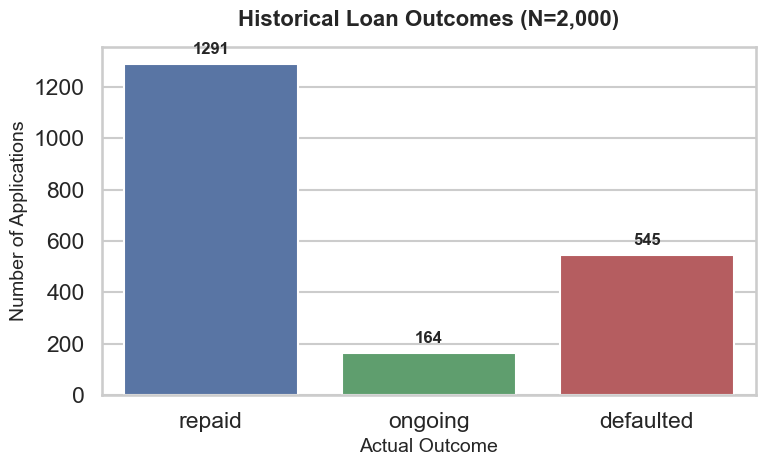

In [8]:
# 1. Target Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=loan_applications, 
    x='actual_outcome', 
    palette=['#4C72B0', '#55A868', '#C44E52'], 
    order=['repaid', 'ongoing', 'defaulted']
)
plt.title('Historical Loan Outcomes (N=2,000)', fontsize=16, weight='bold', pad=15)
plt.ylabel('Number of Applications', fontsize=14)
plt.xlabel('Actual Outcome', fontsize=14)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, weight='bold', 
                xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()


C:\Users\Eric\AppData\Local\Temp\ipykernel_14512\280253975.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=default_by_docs.index, y=default_by_docs.values, palette='magma')
C:\Users\Eric\AppData\Local\Temp\ipykernel_14512\280253975.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Docs Submitted', 'Docs Missing (Null)'])


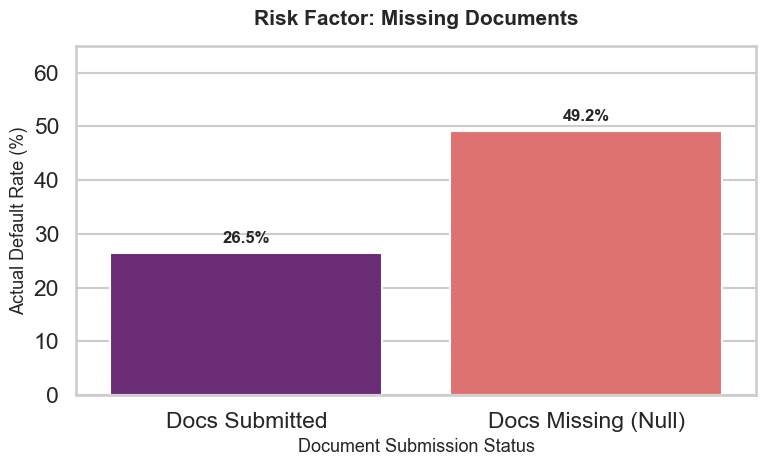

In [9]:
# 2. Risk Factor: Missing Documents
plt.figure(figsize=(8, 5))
default_by_docs = settled_data.groupby('missing_docs')['is_default'].mean() * 100
ax = sns.barplot(x=default_by_docs.index, y=default_by_docs.values, palette='magma')
plt.title('Risk Factor: Missing Documents', fontsize=15, weight='bold', pad=15)
plt.ylabel('Actual Default Rate (%)', fontsize=13)
plt.xlabel('Document Submission Status', fontsize=13)
ax.set_xticklabels(['Docs Submitted', 'Docs Missing (Null)'])
plt.ylim(0, 65)
add_percentages(ax)
plt.tight_layout()
plt.show()


C:\Users\Eric\AppData\Local\Temp\ipykernel_14512\1648767351.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=default_by_income.index, y=default_by_income.values, palette='magma')
C:\Users\Eric\AppData\Local\Temp\ipykernel_14512\1648767351.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No', 'Yes (Misrepresented)'])


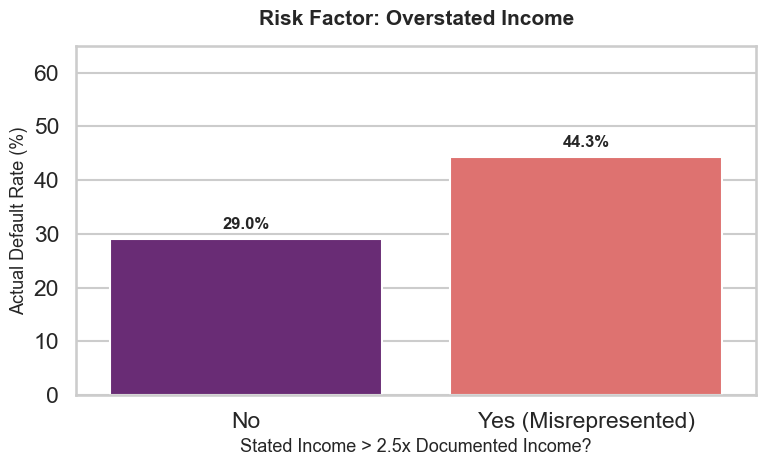

In [10]:
# 3. Risk Factor: Overstated Income
plt.figure(figsize=(8, 5))
default_by_income = settled_data.groupby('overstated_income')['is_default'].mean() * 100
ax = sns.barplot(x=default_by_income.index, y=default_by_income.values, palette='magma')
plt.title('Risk Factor: Overstated Income', fontsize=15, weight='bold', pad=15)
plt.ylabel('Actual Default Rate (%)', fontsize=13)
plt.xlabel('Stated Income > 2.5x Documented Income?', fontsize=13)
ax.set_xticklabels(['No', 'Yes (Misrepresented)'])
plt.ylim(0, 65)
add_percentages(ax)
plt.tight_layout()
plt.show()


C:\Users\Eric\AppData\Local\Temp\ipykernel_14512\413820327.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=default_by_employ_status.index, y=default_by_employ_status.values, palette='magma')
C:\Users\Eric\AppData\Local\Temp\ipykernel_14512\413820327.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Employed', 'Self-Employed', 'Unemployed'])


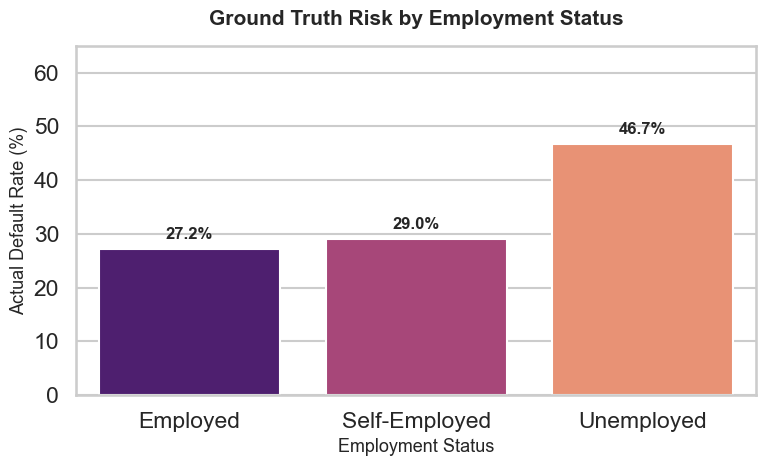

In [11]:
# 4. Ground Truth Risk by Employment Status
plt.figure(figsize=(8, 5))
default_by_employ_status = settled_data.groupby('employment_status')['is_default'].mean() * 100
ax = sns.barplot(x=default_by_employ_status.index, y=default_by_employ_status.values, palette='magma')
plt.title('Ground Truth Risk by Employment Status', fontsize=15, weight='bold', pad=15)
plt.ylabel('Actual Default Rate (%)', fontsize=13)
plt.xlabel('Employment Status', fontsize=13)
ax.set_xticklabels(['Employed', 'Self-Employed', 'Unemployed'])
plt.ylim(0, 65)
add_percentages(ax)
plt.tight_layout()
plt.show()


# 3. Dataset Preparation & Feature Engineering

In [12]:
final_dataset = loan_applications.copy()

# Drop leakage columns and ongoing loans
final_dataset.drop(['applicant_id', 'rule_based_score', 'rule_based_decision', 'days_to_default'], axis=1, inplace=True)
final_dataset = final_dataset[final_dataset["actual_outcome"] != "ongoing"].copy()

# Feature Engineering
final_dataset['overstated_income'] = final_dataset["stated_monthly_income"] > 2.5 * final_dataset["documented_monthly_income"] 
final_dataset['missing_docs'] = final_dataset["documented_monthly_income"].isna()

# Handle nulls
final_dataset['documented_monthly_income'] = final_dataset['documented_monthly_income'].fillna(final_dataset['stated_monthly_income'])

# Define features (X) and target (y)
y_binary = final_dataset['actual_outcome'].map({'defaulted': 1, 'repaid': 0})
X = final_dataset.drop(columns=['actual_outcome'])
X = pd.get_dummies(X, drop_first=True) # One-hot encode employment_status

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

# Scale data for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# 4. Model Building (Logistic Regression)


In [13]:
# Train Model with balanced class weights
clf = LogisticRegression(random_state=0, class_weight='balanced')
clf.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`

# Explainability (Feature Importance)

C:\Users\Eric\AppData\Local\Temp\ipykernel_14512\1674270551.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Eric\AppData\Local\Temp\ipykernel_14512\1674270551.py:10: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


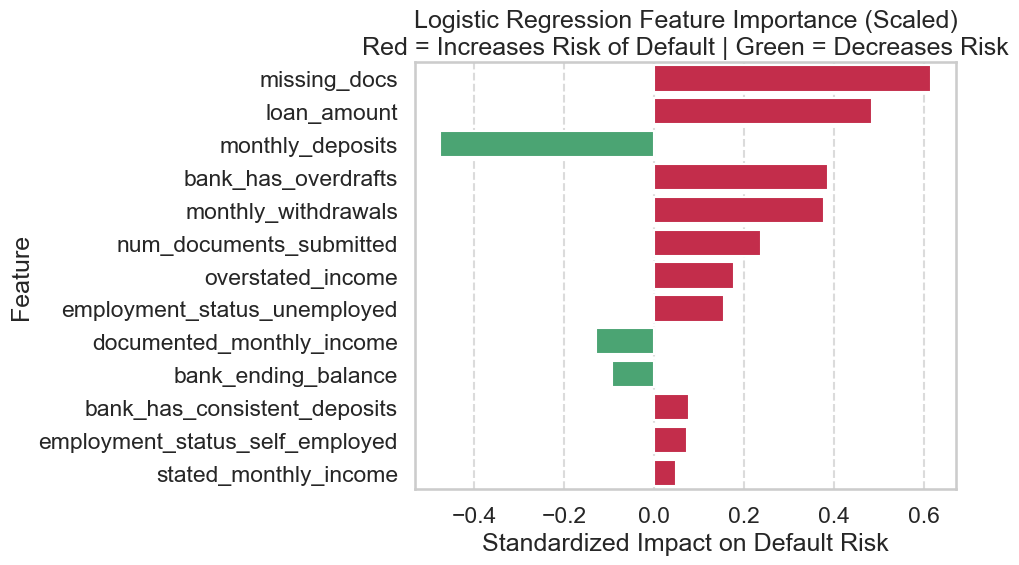

In [14]:
# Extract coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': clf.coef_[0]
})
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=feature_importance,
    palette=np.where(feature_importance['Coefficient'] > 0, 'crimson', 'mediumseagreen')
)

plt.title('Logistic Regression Feature Importance (Scaled)\nRed = Increases Risk of Default | Green = Decreases Risk')
plt.xlabel('Standardized Impact on Default Risk')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# 5. Systematic Threshold Selection (ROC Curve)


In [16]:
# 1. Get raw ML Probabilities and Baseline Decisions
ml_probs = clf.predict_proba(X_test_scaled)[:, 1] 
baseline_decisions = loan_applications.loc[X_test.index, 'rule_based_decision']
baseline_preds = np.where(baseline_decisions == 'approved', 0, 1)

# 2. Calculate the False Positive Rate and True Positive Rate for the BASELINE
base_tn, base_fp, base_fn, base_tp = confusion_matrix(y_test, baseline_preds).ravel()
base_fpr = base_fp / (base_fp + base_tn)
base_tpr = base_tp / (base_tp + base_fn)

# 3. Calculate the ROC curve for our ML model
fpr_ml, tpr_ml, thresholds = roc_curve(y_test, ml_probs)
ml_auc = roc_auc_score(y_test, ml_probs)

# 4. Find the exact threshold that matches the baseline's False Positive Rate
closest_fpr_index = np.argmin(np.abs(fpr_ml - base_fpr))
optimal_threshold = thresholds[closest_fpr_index]
optimal_tpr = tpr_ml[closest_fpr_index]


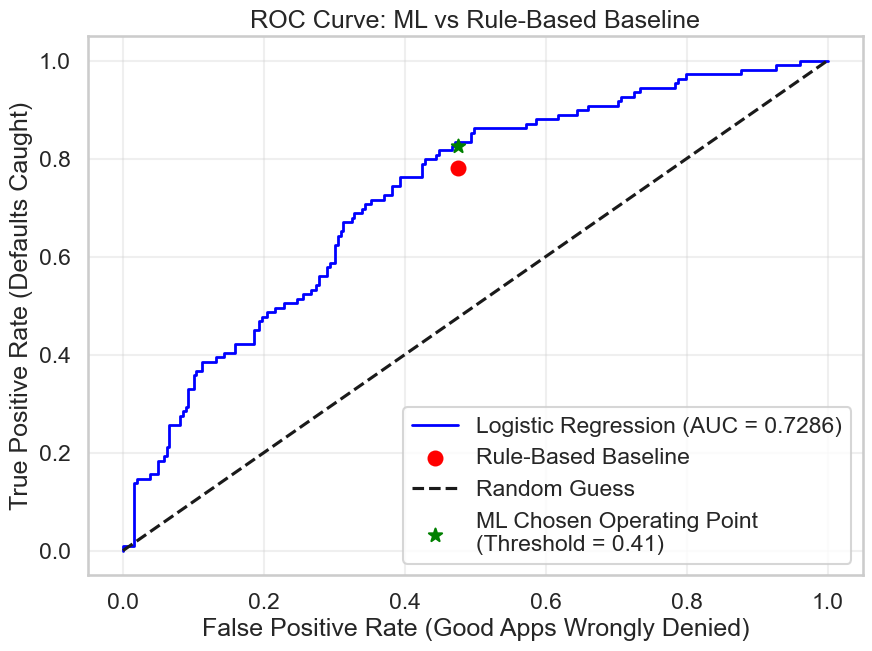

In [17]:
# 5. Plotting the ROC Curve
plt.figure(figsize=(10, 7))
plt.plot(fpr_ml, tpr_ml, label=f'Logistic Regression (AUC = {ml_auc:.4f})', linewidth=2, color='blue')
plt.scatter(base_fpr, base_tpr, color='red', s=100, label='Rule-Based Baseline', zorder=5)
plt.plot([0, 1],[0, 1], 'k--', label='Random Guess')
plt.scatter(base_fpr, optimal_tpr, color='green', s=100, marker='*', zorder=5, 
            label=f'ML Chosen Operating Point\n(Threshold = {optimal_threshold:.2f})')

plt.title('ROC Curve: ML vs Rule-Based Baseline')
plt.xlabel('False Positive Rate (Good Apps Wrongly Denied)')
plt.ylabel('True Positive Rate (Defaults Caught)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [ ]:
print(f"--- SYSTEMATIC THRESHOLD ANALYSIS ---")
print(f"The Rule-Based Baseline operates at an FPR of {base_fpr:.2%} and a TPR of {base_tpr:.2%}.")
print(f"If we match the Baseline's False Positive rate ({base_fpr:.2%}),")
print(f"our ML model achieves a True Positive Rate of {optimal_tpr:.2%} by using a threshold of {optimal_threshold:.2f}.")

--- SYSTEMATIC THRESHOLD ANALYSIS ---
The Rule-Based Baseline operates at an FPR of 47.49% and a TPR of 77.98%.
If we match the Baseline's False Positive rate (47.49%),
our ML model achieves a True Positive Rate of 82.57% by using a threshold of 0.41.


# 6. Evaluation Against Baseline


In [19]:
# Dynamically apply the optimal threshold proved in the ROC step
CUSTOM_THRESHOLD = round(optimal_threshold, 2)
ml_preds = (ml_probs >= CUSTOM_THRESHOLD).astype(int)

def print_all_metrics(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    
    print(f"========== {model_name} ==========")
    print(f"True Positives (Defaults Caught): {tp}")
    print(f"False Positives (Good Apps Denied): {fp}")
    print(f"True Negatives (Correctly Approved): {tn}")
    print(f"False Negatives (Defaults Missed): {fn}")
    print(f"\nFalse Positive Rate (Good applicants denied): {fpr:.2%}")
    print(f"False Negative Rate (Defaults that slipped through): {fnr:.2%}\n")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Repaid (0)', 'Defaulted (1)']))
    print("\n")

print_all_metrics(y_test, baseline_preds, "RULE-BASED BASELINE")
print_all_metrics(y_test, ml_preds, f"LOGISTIC REGRESSION (Threshold={CUSTOM_THRESHOLD})")

print(f"========== AUC-ROC ==========")
print(f"Logistic Regression AUC-ROC: {ml_auc:.4f}")
print("(Baseline does not output probabilities, so AUC-ROC cannot be calculated)")


========== RULE-BASED BASELINE ==========
True Positives (Defaults Caught): 85
False Positives (Good Apps Denied): 123
True Negatives (Correctly Approved): 136
False Negatives (Defaults Missed): 24

False Positive Rate (Good applicants denied): 47.49%
False Negative Rate (Defaults that slipped through): 22.02%

Classification Report:
               precision    recall  f1-score   support

   Repaid (0)       0.85      0.53      0.65       259
Defaulted (1)       0.41      0.78      0.54       109

     accuracy                           0.60       368
    macro avg       0.63      0.65      0.59       368
 weighted avg       0.72      0.60      0.62       368



========== LOGISTIC REGRESSION (Threshold=0.41) ==========
True Positives (Defaults Caught): 91
False Positives (Good Apps Denied): 122
True Negatives (Correctly Approved): 137
False Negatives (Defaults Missed): 18

False Positive Rate (Good applicants denied): 47.10%
False Negative Rate (Defaults that slipped through): 16.51%


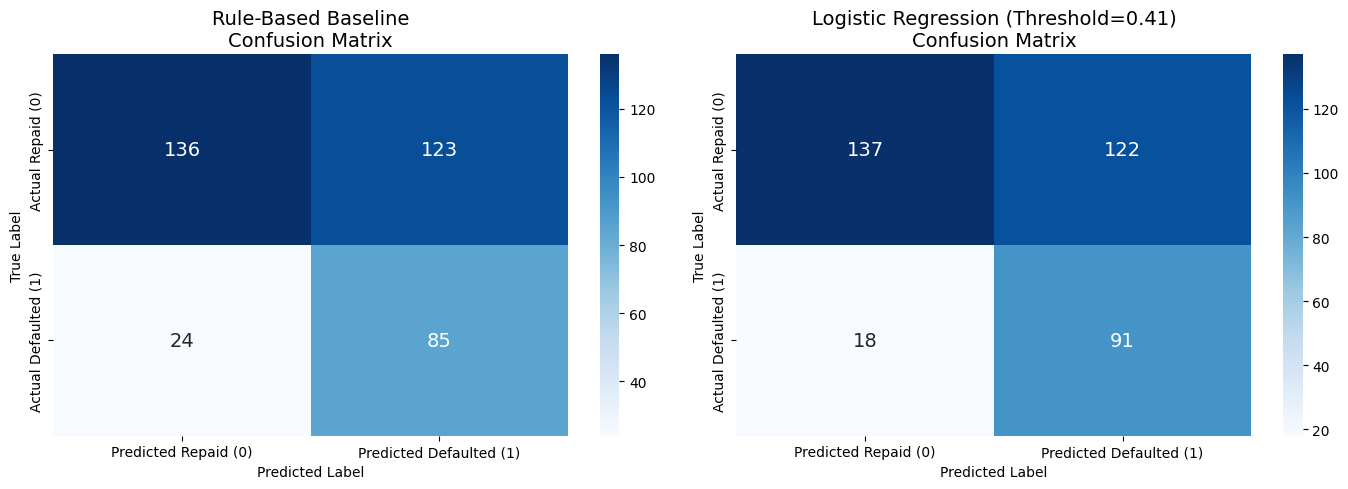

In [23]:
# Generate Visual Confusion Matrices
cm_baseline = confusion_matrix(y_test, baseline_preds)
cm_ml = confusion_matrix(y_test, ml_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline Confusion Matrix (Reds)
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Predicted Repaid (0)', 'Predicted Defaulted (1)'], 
            yticklabels=['Actual Repaid (0)', 'Actual Defaulted (1)'],
            annot_kws={"size": 14})
axes[0].set_title('Rule-Based Baseline\nConfusion Matrix', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ML Confusion Matrix (Blues)
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=['Predicted Repaid (0)', 'Predicted Defaulted (1)'], 
            yticklabels=['Actual Repaid (0)', 'Actual Defaulted (1)'],
            annot_kws={"size": 14})
axes[1].set_title(f'Logistic Regression (Threshold={CUSTOM_THRESHOLD})\nConfusion Matrix', fontsize=14)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

#reset plt settings
plt.rcdefaults()

plt.tight_layout()
plt.show()


# 7. Fairness Analysis

In [25]:
# Create a DataFrame for fairness analysis using our test set
fairness_df = pd.DataFrame(index=X_test.index)
fairness_df['employment_status'] = final_dataset.loc[X_test.index, 'employment_status']
fairness_df['actual_default_rate'] = y_test
fairness_df['actual_repayment_rate'] = 1 - fairness_df['actual_default_rate']

# For approval rates: 1 means Approved (Predicted 0 / Repaid), 0 means Denied (Predicted 1 / Defaulted)
fairness_df['baseline_approved'] = (baseline_preds == 0).astype(int)
fairness_df['ml_approved'] = (ml_preds == 0).astype(int)

# Extract just the numbers for plotting
plot_data = fairness_df.groupby('employment_status').agg(
    Actual_Repayment_Rate=('actual_repayment_rate', lambda x: x.mean() * 100),
    Baseline_Approval_Rate=('baseline_approved', lambda x: x.mean() * 100),
    ML_Approval_Rate=('ml_approved', lambda x: x.mean() * 100)
)

# Reorder to match the logical flow of the chart
plot_data = plot_data.loc[['employed', 'self_employed', 'unemployed']]


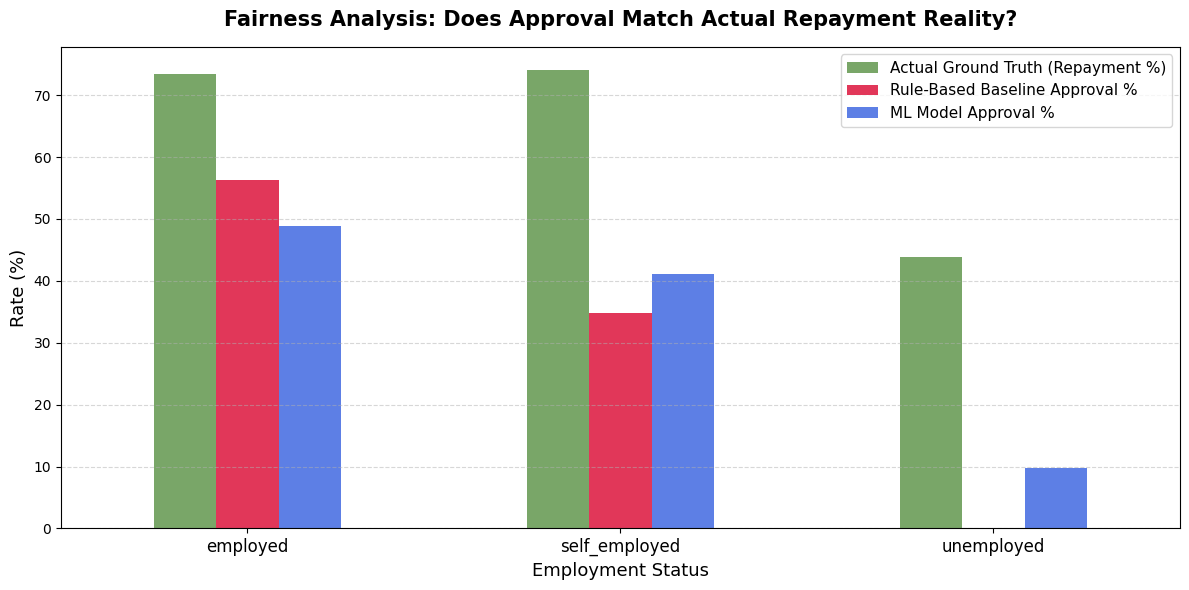

In [26]:
ax = plot_data.plot(
    kind='bar', 
    figsize=(12, 6), 
    color=["#62974DE3", 'crimson', 'royalblue'], 
    alpha=0.85
)

plt.title('Fairness Analysis: Does Approval Match Actual Repayment Reality?', fontsize=15, weight='bold', pad=15)
plt.ylabel('Rate (%)', fontsize=13)
plt.xlabel('Employment Status', fontsize=13)
plt.xticks(rotation=0, fontsize=12)

plt.legend([
    'Actual Ground Truth (Repayment %)', 
    'Rule-Based Baseline Approval %', 
    'ML Model Approval %'
], fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# 8. Business Value / Financial Impact Analysis

In [27]:
# 1. Get the actual loan amounts for our test set
test_loan_amounts = final_dataset.loc[X_test.index, 'loan_amount']

# 2. Get exact counts dynamically
tn_base, fp_base, fn_base, tp_base = confusion_matrix(y_test, baseline_preds).ravel()
tn_ml, fp_ml, fn_ml, tp_ml = confusion_matrix(y_test, ml_preds).ravel()

# 3. Calculate exact principal lost to defaults (False Negatives)
baseline_fn_loss = test_loan_amounts[(y_test == 1) & (baseline_preds == 0)].sum()
ml_fn_loss = test_loan_amounts[(y_test == 1) & (ml_preds == 0)].sum()
principal_saved = baseline_fn_loss - ml_fn_loss

# 4. Calculate exact revenue lost from wrongly denying good loans (False Positives)
EXPRESS_FEE = 5.00 
baseline_fp_revenue_lost = fp_base * EXPRESS_FEE
ml_fp_revenue_lost = fp_ml * EXPRESS_FEE

# Extra revenue we gave up (negative means we GAINED revenue!)
revenue_sacrificed = ml_fp_revenue_lost - baseline_fp_revenue_lost

# 5. Total Net Business Impact
net_value = principal_saved - revenue_sacrificed


In [ ]:
print("--- FINANCIAL IMPACT OF DEPLOYING ML MODEL (Test Set: 368 Apps) ---")
print(f"Baseline Principal Lost ({fn_base} missed defaults): ${baseline_fn_loss:,.2f}")
print(f"ML Principal Lost       ({fn_ml} missed defaults): ${ml_fn_loss:,.2f}")
print(f"-> Principal Capital Saved by ML Model:       +${principal_saved:,.2f}\n")

print(f"Baseline Fees Lost ({fp_base} wrongly denied):      ${baseline_fp_revenue_lost:,.2f}")
print(f"ML Fees Lost       ({fp_ml} wrongly denied):      ${ml_fp_revenue_lost:,.2f}")

if revenue_sacrificed < 0:
    print(f"-> Revenue Gained by ML Model:                +${abs(revenue_sacrificed):,.2f}\n")
else:
    print(f"-> Revenue Sacrificed by ML Model:            -${revenue_sacrificed:,.2f}\n")

print(f"======================================================")
print(f"NET VALUE ADDED BY ML MODEL:                  +${net_value:,.2f}")
print(f"======================================================")


--- FINANCIAL IMPACT OF DEPLOYING ML MODEL (Test Set: 368 Apps) ---
Baseline Principal Lost (24 missed defaults): $33,500.00
ML Principal Lost       (18 missed defaults): $25,500.00
-> Principal Capital Saved by ML Model:       +$8,000.00

Baseline Fees Lost (123 wrongly denied):      $615.00
ML Fees Lost       (122 wrongly denied):      $610.00
-> Revenue Gained by ML Model:                +$5.00

NET VALUE ADDED BY ML MODEL:                  +$8,005.00
